In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.model_selection import cross_val_score
import joblib

In [3]:
data = pd.read_csv("indian _Summer_Weather.csv")
data


,City,Date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,windspeed,winddir,sealevelpressure,cloudcover,visibility,sunrise,sunset,moonphase,conditions,description
0,New Delhi,01-04-2021,34.0,19.0,27.1,31.6,19.0,26.1,3.1,22.60,22.8,272.9,1002.8,0.0,3.1,01-04-2021 06:11,01-04-2021 18:39,0.60,Clear,Clear conditions throughout the day.
1,New Delhi,02-04-2021,33.9,16.0,25.8,31.8,16.0,24.9,4.5,27.62,12.4,275.0,1006.2,0.0,3.5,02-04-2021 06:10,02-04-2021 18:39,0.65,Clear,Clear conditions throughout the day.
2,New Delhi,03-04-2021,34.8,14.6,26.0,32.2,14.6,25.1,1.3,23.18,16.5,127.5,1008.8,1.4,3.5,03-04-2021 06:08,03-04-2021 18:40,0.70,Clear,Clear conditions throughout the day.
3,New Delhi,04-04-2021,36.8,16.9,27.1,34.2,16.9,26.0,4.8,28.00,18.3,157.6,1009.5,2.6,3.2,04-04-2021 06:07,04-04-2021 18:40,0.76,Clear,Clear conditions throughout the day.
4,New Delhi,05-04-2021,38.8,21.0,29.9,37.1,21.0,28.9,8.1,28.85,13.5,100.4,1007.8,38.4,3.1,05-04-2021 06:06,05-04-2021 18:41,0.81,Partially cloudy,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20377,Hyderabad,26-06-2007,29.1,23.1,26.5,30.9,23.1,27.6,21.3,73.67,24.1,NaN,NaN,97.6,3.4,26-06-2007 05:43,26-06-2007 18:53,0.42,"Rain, Overcast",Cloudy skies throughout the day with afternoon...
20378,Hyderabad,27-06-2007,29.1,24.1,26.3,32.9,24.1,27.3,21.4,74.96,27.7,NaN,NaN,93.8,4.3,27-06-2007 05:44,27-06-2007 18:53,0.45,"Rain, Overcast",Cloudy skies throughout the day with rain.
20379,Hyderabad,28-06-2007,29.1,25.1,26.8,31.4,25.1,27.7,20.6,69.17,27.7,NaN,NaN,93.8,4.6,28-06-2007 05:44,28-06-2007 18:54,0.48,"Rain, Overcast",Cloudy skies throughout the day with late afte...
20380,Hyderabad,29-06-2007,27.1,24.1,26.2,28.6,24.1,26.9,20.3,70.24,25.9,NaN,NaN,98.8,5.0,29-06-2007 05:44,29-06-2007 18:54,0.49,"Rain, Overcast",Cloudy skies throughout the day with rain.


In [4]:
# Handling missing values (if any)
# Select only numeric columns for calculating mean
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())


In [5]:
# Convert float values to strings before applying the lambda function
data['conditions'] = data['conditions'].astype(str)

# Convert categorical variables to numerical values
data['conditions_binary'] = data['conditions'].apply(lambda x: 1 if 'Clear' in x else 0)

In [6]:
# Remove non-numeric columns from numerical_features list
numerical_features = ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 
                      'dew', 'humidity', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 
                      'visibility', 'sunrise', 'sunset', 'moonphase']

# Exclude non-numeric columns
numerical_features = [col for col in numerical_features if data[col].dtype != 'object']

# Apply StandardScaler to numerical features
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

Data Preprocessing - Data Cleaning

In [7]:
imputer = SimpleImputer(strategy='mean')
data['cloudcover'].fillna(data['cloudcover'].mean(), inplace=True)
data['visibility'].fillna(data['visibility'].mean(), inplace=True)
print("\nData after preprocessing:")
print(data.head())
print("\nSummary of 'cloudcover' column after handling missing values:")
print(data['cloudcover'].describe())

print("\nSummary of 'visibility' column after handling missing values:")
print(data['visibility'].describe())


Data after preprocessing:
        City        Date   tempmax   tempmin      temp  feelslikemax  \
0  New Delhi  01-04-2021 -0.669190 -2.170442 -1.312702     -1.605832   
1  New Delhi  02-04-2021 -0.693575 -3.127902 -1.739881     -1.567535   
2  New Delhi  03-04-2021 -0.474115 -3.574717 -1.674162     -1.490940   
3  New Delhi  04-04-2021  0.013573 -2.840664 -1.312702     -1.107968   
4  New Delhi  05-04-2021  0.501261 -1.532135 -0.392624     -0.552657   

   feelslikemin  feelslike       dew  humidity  ...   winddir  \
0     -1.711557  -1.633619 -2.609699 -1.614852  ...  1.027552   
1     -2.343554  -1.898529 -2.377476 -1.358686  ...  1.061286   
2     -2.638485  -1.854377 -2.908270 -1.585255  ... -1.308115   
3     -2.153955  -1.655694 -2.327715 -1.339295  ... -0.824597   
4     -1.290227  -1.015495 -1.780334 -1.295920  ... -1.743442   

   sealevelpressure  cloudcover  visibility           sunrise  \
0         -0.401714   -1.490940   -1.150490  01-04-2021 06:11   
1          0.610044

 Exploratory Data Analysis (EDA)




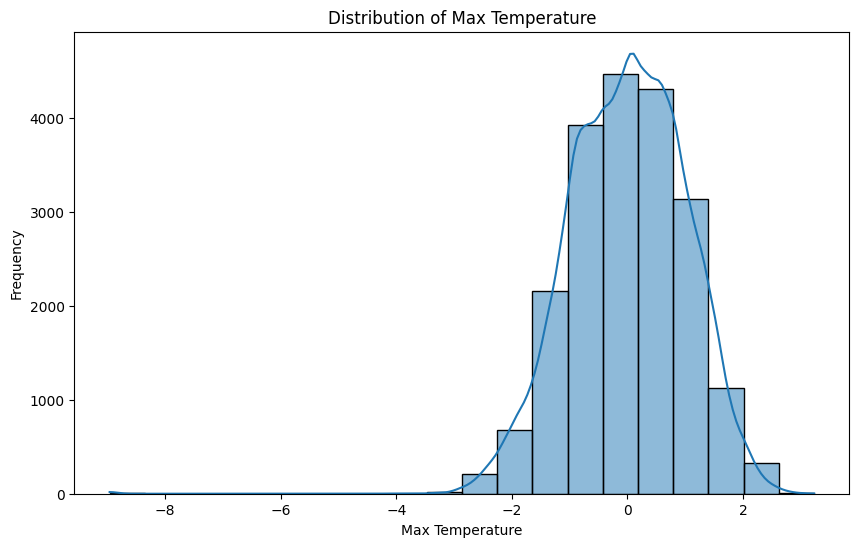

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data['tempmax'], bins=20, kde=True)
plt.title('Distribution of Max Temperature')
plt.xlabel('Max Temperature')
plt.ylabel('Frequency')
plt.show()

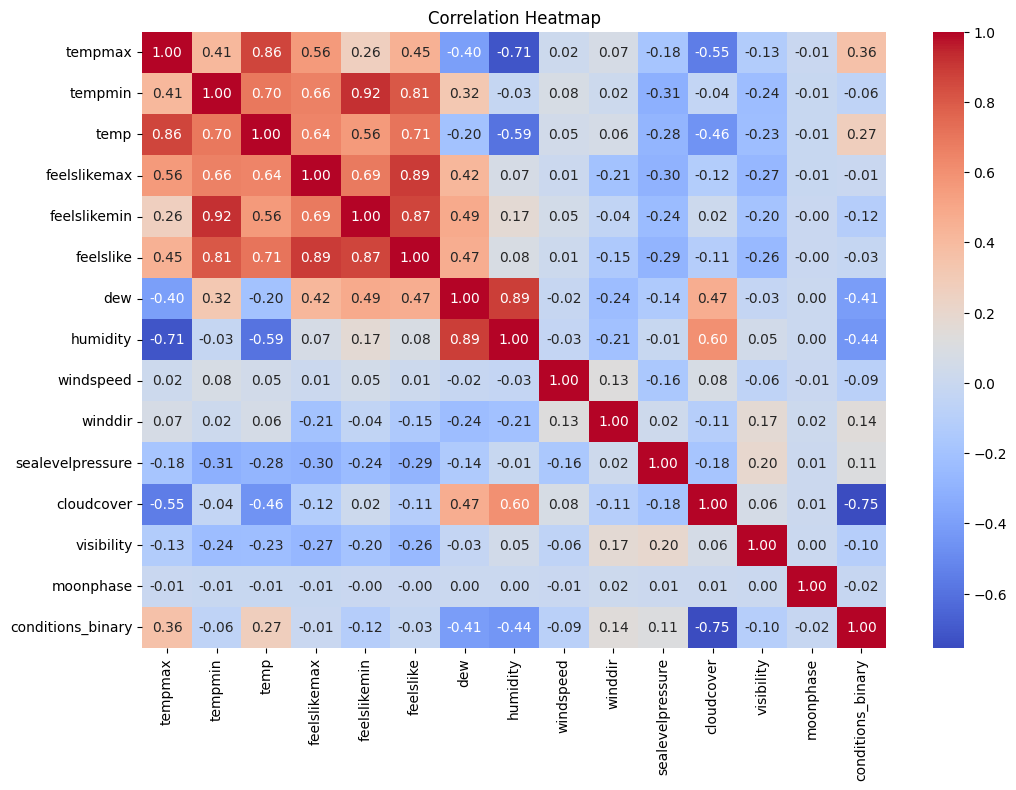

In [9]:
# Exclude non-numeric columns from correlation calculation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()



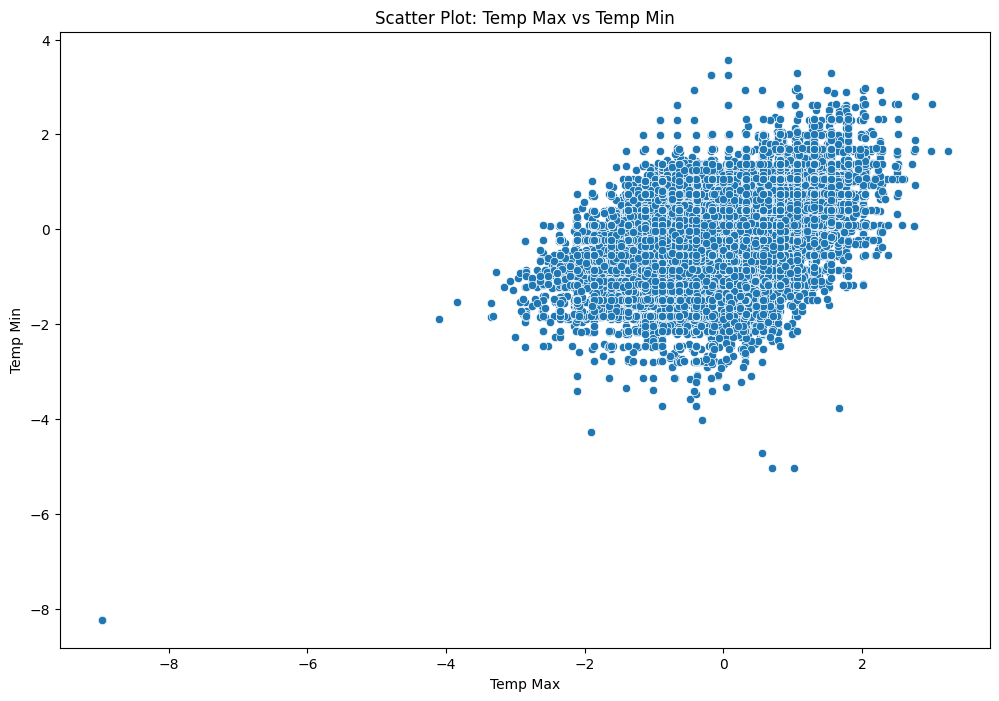

In [10]:
# Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='tempmax', y='tempmin', data=data)
plt.title('Scatter Plot: Temp Max vs Temp Min')
plt.xlabel('Temp Max')
plt.ylabel('Temp Min')
plt.show()

Feature selection -logic

In [11]:
X_max_temp = data[['City', 'Date', 'tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'dew', 'humidity', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility']]
y_max_temp = data['tempmax']

X_min_temp = data[['City', 'Date', 'tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'dew', 'humidity', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility']]
y_min_temp = data['tempmin']

X_humidity = data[['City', 'Date', 'tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'dew', 'humidity', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility']]
y_humidity = data['humidity']

X_windspeed = data[['City', 'Date', 'tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'dew', 'humidity', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility']]
y_windspeed = data['windspeed']

In [12]:
X = data[numerical_features]
y = data['conditions_binary']

Split the data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
# Split Data into training and testing sets
X_train_max_temp, X_test_max_temp, y_train_max_temp, y_test_max_temp = train_test_split(X_max_temp, y_max_temp, test_size=0.2, random_state=42)
X_train_min_temp, X_test_min_temp, y_train_min_temp, y_test_min_temp = train_test_split(X_min_temp, y_min_temp, test_size=0.2, random_state=42)
X_train_humidity, X_test_humidity, y_train_humidity, y_test_humidity = train_test_split(X_humidity, y_humidity, test_size=0.2, random_state=42)
X_train_windspeed, X_test_windspeed, y_train_windspeed, y_test_windspeed = train_test_split(X_windspeed, y_windspeed, test_size=0.2, random_state=42)

train the model 

In [15]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Accuracy: 0.9952575633687654


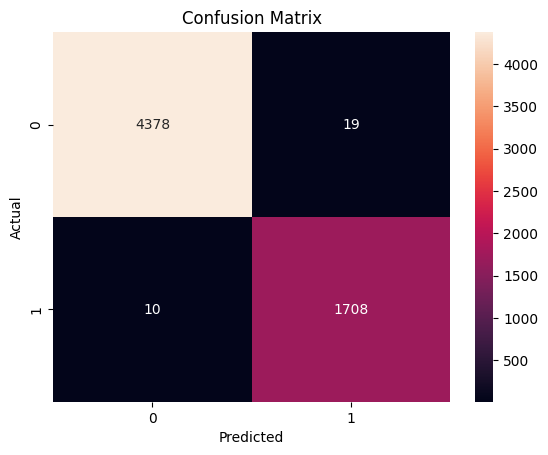

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4397
           1       0.99      0.99      0.99      1718

    accuracy                           1.00      6115
   macro avg       0.99      0.99      0.99      6115
weighted avg       1.00      1.00      1.00      6115



In [16]:
#Evaluate the model
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))



Feature Selection -linear 


In [17]:
selected_features = ['tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'dew', 'humidity', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility']
X = data[selected_features]
y = data['temp']
print("Selected features (X):")
print(X.head())

print("\nTarget variable (y):")
print(y.head())

Selected features (X):
    tempmax   tempmin  feelslikemax  feelslikemin       dew  humidity  \
0 -0.669190 -2.170442     -1.605832     -1.711557 -2.609699 -1.614852   
1 -0.693575 -3.127902     -1.567535     -2.343554 -2.377476 -1.358686   
2 -0.474115 -3.574717     -1.490940     -2.638485 -2.908270 -1.585255   
3  0.013573 -2.840664     -1.107968     -2.153955 -2.327715 -1.339295   
4  0.501261 -1.532135     -0.552657     -1.290227 -1.780334 -1.295920   

   windspeed  sealevelpressure  cloudcover  visibility  
0   0.233915         -0.401714   -1.490940   -1.150490  
1  -0.866541          0.610044   -1.490940   -0.865098  
2  -0.432707          1.383741   -1.436033   -0.865098  
3  -0.242244          1.592044   -1.388970   -1.079142  
4  -0.750147          1.086165    0.015076   -1.150490  

Target variable (y):
0   -1.312702
1   -1.739881
2   -1.674162
3   -1.312702
4   -0.392624
Name: temp, dtype: float64


 Feature Engineering



In [18]:
categorical_features = ['conditions']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_categories = encoder.fit_transform(data[categorical_features])
X_encoded = pd.concat([X, pd.DataFrame(encoded_categories, columns=encoder.get_feature_names_out(categorical_features))], axis=1)
print(X_encoded)

        tempmax   tempmin  feelslikemax  feelslikemin       dew  humidity  \
0     -0.669190 -2.170442     -1.605832     -1.711557 -2.609699 -1.614852   
1     -0.693575 -3.127902     -1.567535     -2.343554 -2.377476 -1.358686   
2     -0.474115 -3.574717     -1.490940     -2.638485 -2.908270 -1.585255   
3      0.013573 -2.840664     -1.107968     -2.153955 -2.327715 -1.339295   
4      0.501261 -1.532135     -0.552657     -1.290227 -1.780334 -1.295920   
...         ...       ...           ...           ...       ...       ...   
20377 -1.864026 -0.861912     -1.739873     -0.847829  0.409189  0.991200   
20378 -1.864026 -0.542759     -1.356900     -0.637164  0.425776  1.057027   
20379 -1.864026 -0.223605     -1.644130     -0.426498  0.293078  0.761569   
20380 -2.351714 -0.542759     -2.180292     -0.637164  0.243316  0.816170   
20381 -2.107870 -0.542759     -2.046251     -0.637164  0.243316  0.825866   

       windspeed  sealevelpressure  cloudcover  visibility  conditions_Clea

Feature Scaling


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)
print(X_scaled_df)

        tempmax   tempmin  feelslikemax  feelslikemin       dew  humidity  \
0     -0.669190 -2.170442     -1.605832     -1.711557 -2.609699 -1.614852   
1     -0.693575 -3.127902     -1.567535     -2.343554 -2.377476 -1.358686   
2     -0.474115 -3.574717     -1.490940     -2.638485 -2.908270 -1.585255   
3      0.013573 -2.840664     -1.107968     -2.153955 -2.327715 -1.339295   
4      0.501261 -1.532135     -0.552657     -1.290227 -1.780334 -1.295920   
...         ...       ...           ...           ...       ...       ...   
20377 -1.864026 -0.861912     -1.739873     -0.847829  0.409189  0.991200   
20378 -1.864026 -0.542759     -1.356900     -0.637164  0.425776  1.057027   
20379 -1.864026 -0.223605     -1.644130     -0.426498  0.293078  0.761569   
20380 -2.351714 -0.542759     -2.180292     -0.637164  0.243316  0.816170   
20381 -2.107870 -0.542759     -2.046251     -0.637164  0.243316  0.825866   

       windspeed  sealevelpressure  cloudcover  visibility  conditions_Clea

Split Data into Training and Testing Sets


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("X_train:")
print(X_train)
print("\nX_test:")
print(X_test)
print("\ny_train:")
print(y_train)
print("\ny_test:")
print(y_test)

X_train:
[[ 0.98894919  0.09554839 -0.22713019 ... -0.10915769 -0.39558962
  -0.04858578]
 [-0.27903986 -0.19168978 -0.20798155 ... -0.10915769 -0.39558962
  -0.04858578]
 [ 1.64732812 -0.86191218  0.67285591 ... -0.10915769 -0.39558962
  -0.04858578]
 ...
 [ 0.5256455  -0.41509725  0.21328854 ... -0.10915769 -0.39558962
  -0.04858578]
 [-0.05958022 -0.25552049 -0.82073804 ... -0.10915769 -0.39558962
  -0.04858578]
 [ 2.5739355   0.09554839  1.40050424 ... -0.10915769 -0.39558962
  -0.04858578]]

X_test:
[[-0.40096189  0.09554839  0.97923415 ... -0.10915769 -0.39558962
  -0.04858578]
 [ 1.037718    1.59556996  1.87922025 ... -0.10915769 -0.39558962
  -0.04858578]
 [-1.05934082 -1.53213459 -1.26115677 ... -0.10915769  2.52787218
  -0.04858578]
 ...
 [-0.88864998 -1.50021924 -1.03137309 ... -0.10915769 -0.39558962
  -0.04858578]
 [ 0.81825835 -0.22360513  0.59626135 ... -0.10915769 -0.39558962
  -0.04858578]
 [ 0.0623418   1.02109361  1.45795016 ... -0.10915769 -0.39558962
  -0.04858578]

Build the ML Model

In [21]:

# Assuming X_train and y_train are your training data
# Let's first identify rows with NaN values in X_train
nan_indices = np.isnan(X_train).any(axis=1)

# Remove rows with NaN values from X_train and align y_train
X_train_cleaned = X_train[~nan_indices]
y_train_cleaned = y_train[~nan_indices]

# Now we create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_cleaned, y_train_cleaned)



LinearRegression()

 Model Evaluation

In [22]:
nan_indices_test = np.isnan(X_test).any(axis=1)
X_test_cleaned = X_test[~nan_indices_test]
y_test_cleaned = y_test[~nan_indices_test]

# Now, make predictions with the cleaned test data
y_pred = model.predict(X_test_cleaned)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_cleaned, y_pred)
mse = mean_squared_error(y_test_cleaned, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_cleaned, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)

Mean Absolute Error: 0.155730710087467
Mean Squared Error: 0.05957257771866536
Root Mean Squared Error: 0.24407494283245332
R^2 Score: 0.9390074508833566


 Hyperparameter Tuning



In [23]:
# Handle NaN values in X_train using SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

# Define the pipeline with the model
pipeline = Pipeline([
    ('model', Ridge(max_iter=5000))  # Increase max_iter here
])

# Define the parameter grid for the model
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],  
    'model__fit_intercept': [True, False],
}



Fitting 5 folds for each of 12 candidates, totalling 60 fits


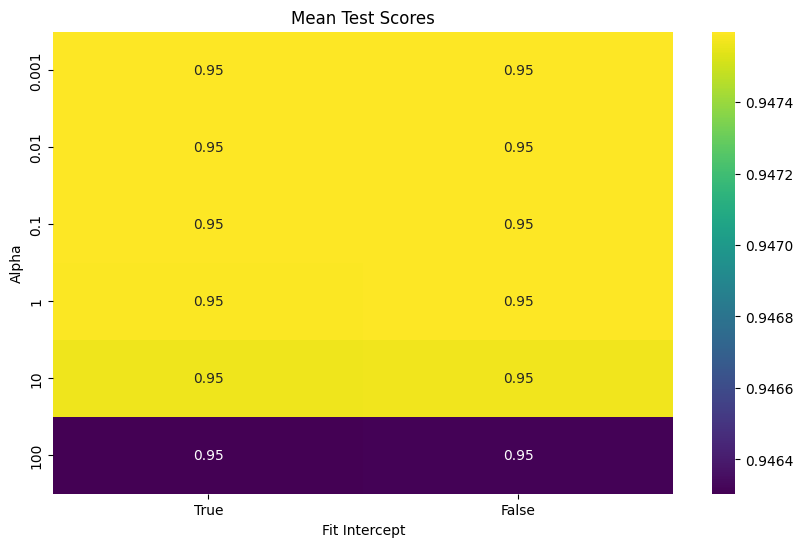

Best parameters found:  {'model__alpha': 0.001, 'model__fit_intercept': False}


In [24]:
# Create the GridSearchCV object
y_train_imputed = y_train.fillna(y_train.mean())
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search
grid_search.fit(X_train_imputed, y_train_imputed)

# Extract the results
results = grid_search.cv_results_

# Extract the mean test scores
mean_test_scores = np.array(results['mean_test_score']).reshape(len(param_grid['model__alpha']), len(param_grid['model__fit_intercept']))

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(mean_test_scores, annot=True, cmap='viridis', xticklabels=param_grid['model__fit_intercept'], yticklabels=param_grid['model__alpha'])
plt.title('Mean Test Scores')
plt.xlabel('Fit Intercept')
plt.ylabel('Alpha')
plt.show()
# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Max Humidity City: Kolkata
Min Humidity City: Jaipur
Mean Humidity: -0.004030557934897076


Text(0.5, 1.0, 'Mean Humidity by City')

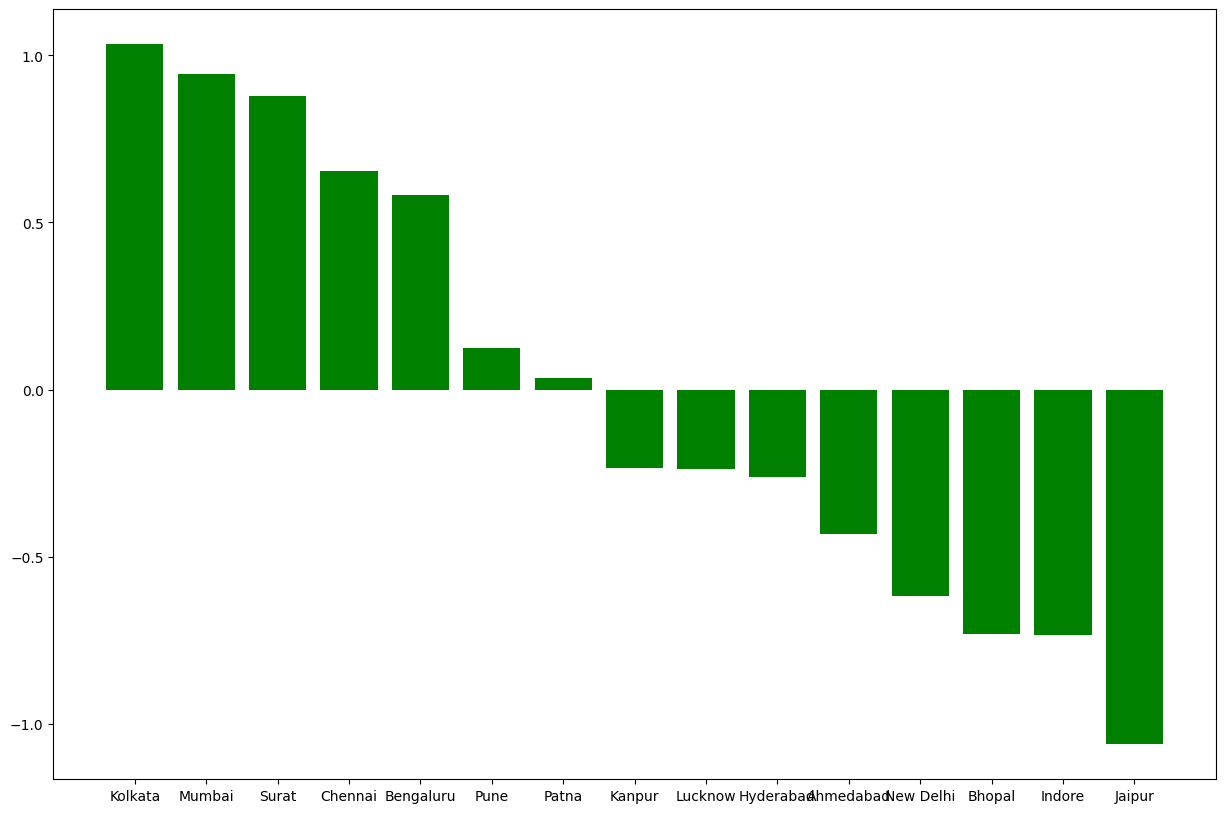

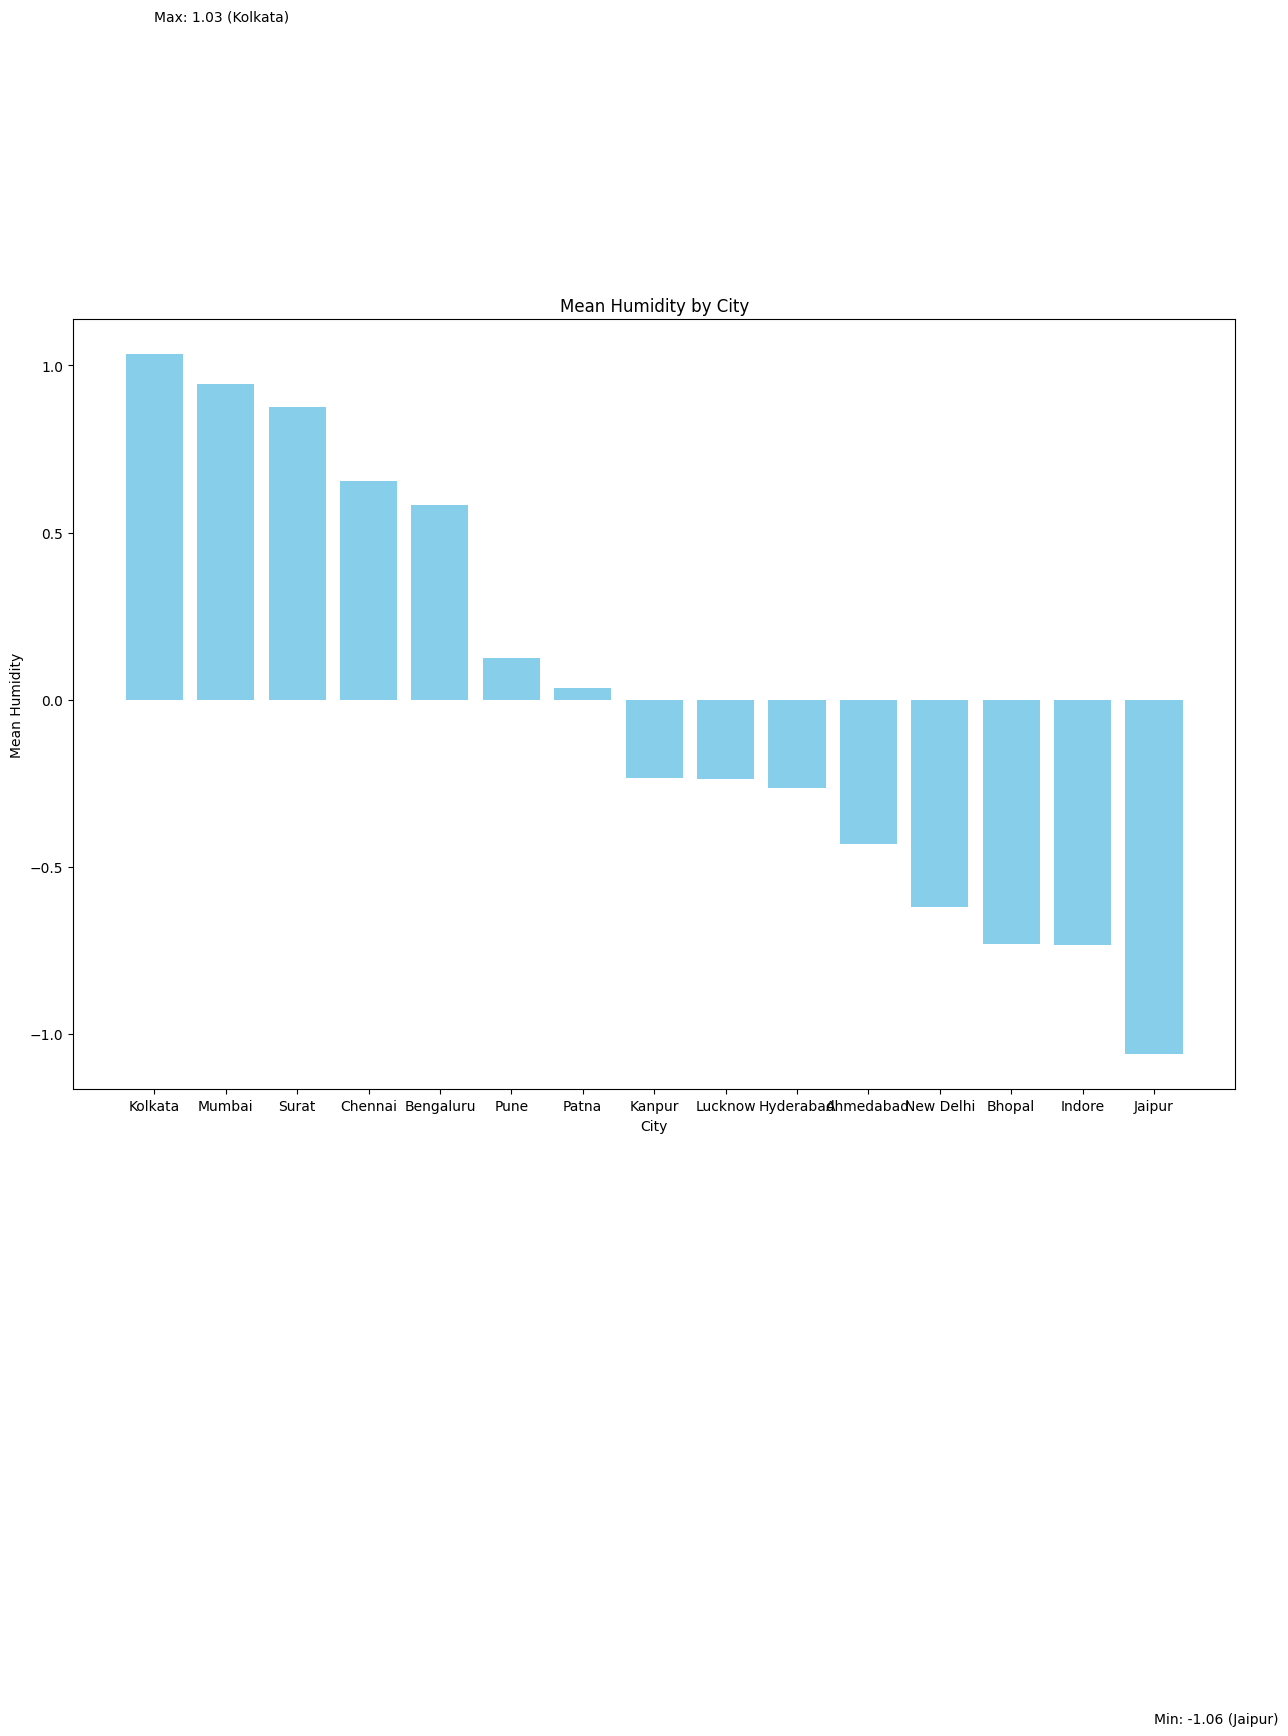

In [40]:
# Calculate mean humidity by city
humidity_mean_by_city = data.groupby('City')['humidity'].mean().sort_values(ascending=False)

# Plotting the bar plot
plt.figure(figsize=(15, 10))
plt.bar(humidity_mean_by_city.index, humidity_mean_by_city.values, color='green')

# Print max_humidity_city, min_humidity_city, and mean humidity
max_humidity_city = humidity_mean_by_city.index[0]
min_humidity_city = humidity_mean_by_city.index[-1]
mean_humidity = humidity_mean_by_city.mean()
print(f"Max Humidity City: {max_humidity_city}")
print(f"Min Humidity City: {min_humidity_city}")
print(f"Mean Humidity: {mean_humidity}")

# Plotting the bar plot
plt.figure(figsize=(15, 10))
plt.bar(humidity_mean_by_city.index, humidity_mean_by_city.values, color='skyblue')

# Annotate max and min humidity
plt.text(0, humidity_mean_by_city.iloc[0] + 1, f'Max: {humidity_mean_by_city.iloc[0]:.2f} ({max_humidity_city})', fontsize=10, color='black')
plt.text(len(humidity_mean_by_city) - 1, humidity_mean_by_city.iloc[-1] - 2, f'Min: {humidity_mean_by_city.iloc[-1]:.2f} ({min_humidity_city})', fontsize=10, color='black')

# Adding labels and title
plt.xlabel('City')
plt.ylabel('Mean Humidity')
plt.title('Mean Humidity by City')


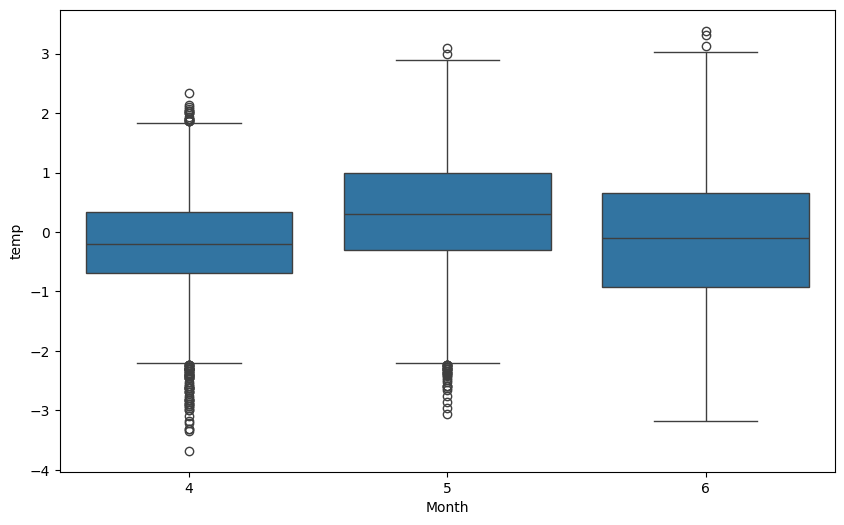

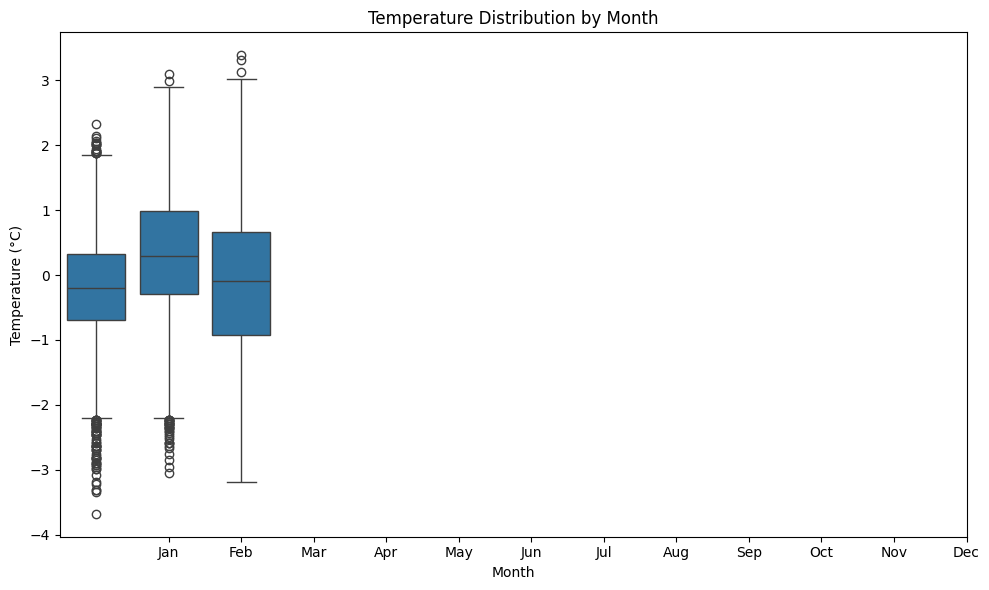

In [26]:
data['Month'] = pd.to_datetime(data['Date'], format='%d-%m-%Y').dt.month
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Month', y='temp')
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Month', y='temp')
plt.title('Temperature Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

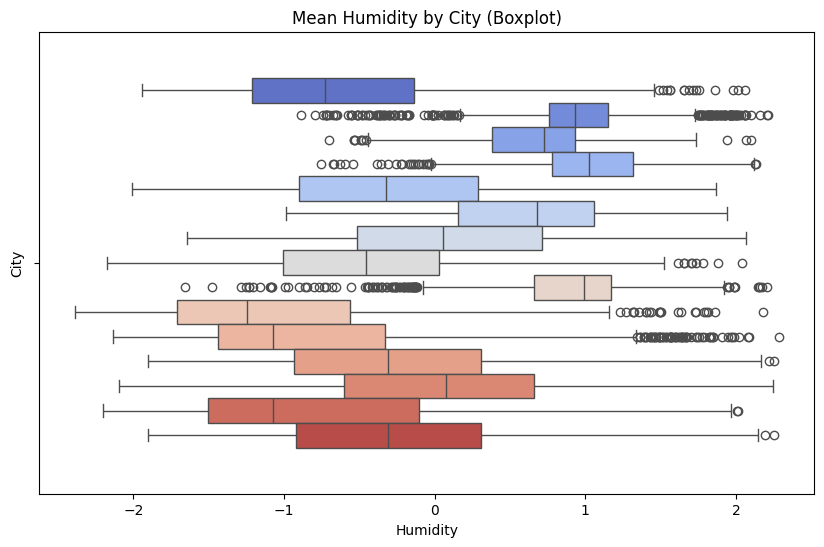

In [27]:
# Calculate mean humidity by city
humidity_mean_by_city = data.groupby('City')['humidity'].mean().sort_values(ascending=False)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['humidity'], hue=data['City'], palette='coolwarm', legend=False)
plt.xlabel('Humidity')
plt.ylabel('City')
plt.title('Mean Humidity by City (Boxplot)')
plt.show()

Save the Model

In [28]:
joblib.dump(grid_search.best_estimator_, 'indian_summer_weather_model.pkl')

['indian_summer_weather_model.pkl']

Test with Unseen Data

In [29]:
saved_model = joblib.load('indian_summer_weather_model.pkl')

Predict with unseen data

In [30]:
# Step 1: Check the names of the steps in your saved model pipeline
step_names = saved_model.named_steps.keys()
print("Step names:", step_names)

# Step 2: Check if 'preprocessing' is in the step names
if 'preprocessing' in step_names:
    # If 'preprocessing' is present, access the step and get the number of expected features
    num_expected_features = saved_model.named_steps['preprocessing'].transformer_.n_features_in_
    
    # Step 2: Adjust the unseen data if necessary
    num_unseen_features = unseen_data.shape[1]
    if num_unseen_features != num_expected_features:
        # If the number of features is not equal, adjust the unseen data
        if num_unseen_features < num_expected_features:
            # Add missing features
            missing_features = num_expected_features - num_unseen_features
            unseen_data = np.hstack((unseen_data, np.zeros((unseen_data.shape[0], missing_features))))
        elif num_unseen_features > num_expected_features:
            # Remove excess features
            unseen_data = unseen_data[:, :num_expected_features]
else:
    print("No preprocessing step found in the saved model pipeline.")

Step names: dict_keys(['model'])
No preprocessing step found in the saved model pipeline.


Predicted Temperature for Unseen Data: [ 3.24065373e-01  2.88341925e-01  2.64739695e-01  2.63373924e-01
  2.62434956e-01  2.42597133e-01  2.38220975e-01  2.34778094e-01
  2.34712432e-01  2.34470795e-01  2.23139164e-01  2.21060631e-01
  2.20949662e-01  2.20894178e-01  2.15796011e-01  2.15059775e-01
  2.10753328e-01  2.06443680e-01  2.05755460e-01  2.05520718e-01
  2.01960568e-01  1.99602377e-01  1.97280363e-01  1.97141790e-01
  1.96036536e-01  1.91639589e-01  1.89922206e-01  1.88290663e-01
  1.88232395e-01  1.85794901e-01  1.85117448e-01  1.85051782e-01
  1.80755448e-01  1.76879159e-01  1.75494439e-01  1.75209991e-01
  1.67268328e-01  1.66928121e-01  1.66873667e-01  1.63122212e-01
  1.62913476e-01  1.58065511e-01  1.55905927e-01  1.55893753e-01
  1.53069311e-01  1.50326407e-01  1.49673488e-01  1.49499484e-01
  1.39340013e-01  1.32714720e-01  1.32072927e-01  1.29857614e-01
  1.28104939e-01  1.27320874e-01  1.21275274e-01  1.14779571e-01
  1.13704543e-01  1.12652478e-01  1.08541831e-01  1

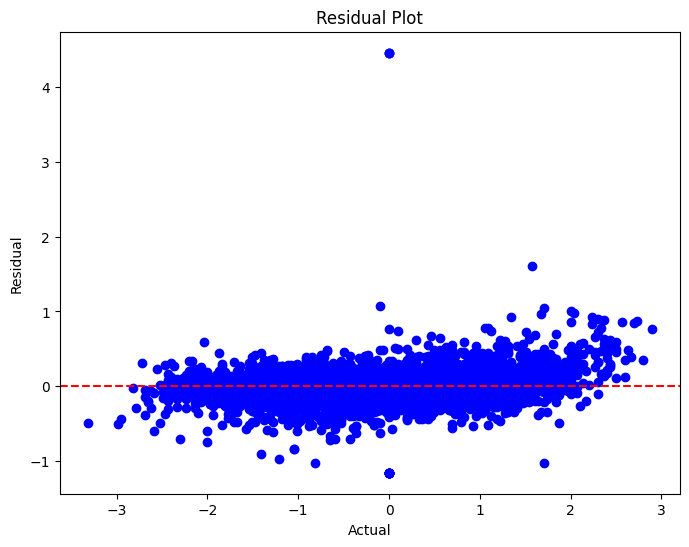

In [31]:
# Assuming you have unseen data stored in the variable `unseen_data`

#unseen_data = np.array([[25.0, 60.0], [30.0, 55.0], [20.0, 70.0]])
unseen_data = data.groupby('temp')['humidity'].mean().sort_values(ascending=False)

# Convert unseen_data to DataFrame if it's a Series
if isinstance(unseen_data, pd.Series):
    unseen_data = unseen_data.to_frame()

# Assuming you need to add missing features to unseen_data to match the model's expectations
num_expected_features = 17

# Check the number of features in unseen_data
num_unseen_features = unseen_data.shape[1]

if num_unseen_features != num_expected_features:
    if num_unseen_features < num_expected_features:
        # Add missing features
        missing_features = num_expected_features - num_unseen_features
        unseen_data = np.hstack((unseen_data, np.zeros((unseen_data.shape[0], missing_features))))
    elif num_unseen_features > num_expected_features:
        # Remove excess features
        unseen_data = unseen_data[:, :num_expected_features]

# Now the unseen_data has the correct number of features
# You can proceed to make predictions with the Ridge model
predicted_temperature = saved_model.predict(unseen_data)
print("Predicted Temperature for Unseen Data:", predicted_temperature)
 
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()


Interpretation of Results (Conclusion

In [41]:
print("\n--- Interpretation of Results (Conclusion) ---")

# Mean Absolute Error (MAE): Represents the average absolute difference between the predicted values and the actual values. 
# A lower MAE indicates better performance, with 0 being the perfect score.
print("Mean Absolute Error (MAE):")
if mae < 0.5:
    print("The model's MAE is very low, indicating excellent accuracy in predicting the target variable.")
elif 0.5 <= mae < 1:
    print("The model's MAE is moderate, suggesting reasonable accuracy in predicting the target variable.")
else:
    print("The model's MAE is relatively high, indicating poor accuracy in predicting the target variable.")

# Mean Squared Error (MSE): Represents the average of the squares of the errors. 
# It is useful for understanding the spread of errors. Lower values are better.
print("\nMean Squared Error (MSE):")
if mse < 1:
    print("The model's MSE is very low, indicating excellent precision in predicting the target variable.")
elif 1 <= mse < 5:
    print("The model's MSE is moderate, suggesting reasonable precision in predicting the target variable.")
else:
    print("The model's MSE is relatively high, indicating poor precision in predicting the target variable.")

# Root Mean Squared Error (RMSE): Represents the square root of the MSE. 
# It's interpretable in the same units as the target variable.
print("\nRoot Mean Squared Error (RMSE):")
if rmse < 1:
    print("The model's RMSE is very low, indicating excellent accuracy in predicting the target variable.")
elif 1 <= rmse < 2:
    print("The model's RMSE is moderate, suggesting reasonable accuracy in predicting the target variable.")
else:
    print("The model's RMSE is relatively high, indicating poor accuracy in predicting the target variable.")

# R-squared (R2) Score: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
# It ranges from 0 to 1, where 1 indicates a perfect fit.
print("\nR-squared (R2) Score:")
if r2 > 0.8:
    print("The model explains a significant portion of the variance in the target variable, indicating a strong fit.")
elif 0.6 <= r2 <= 0.8:
    print("The model explains a moderate portion of the variance in the target variable, suggesting a reasonable fit.")
else:
    print("The model explains a relatively small portion of the variance in the target variable, indicating a weak fit.")



--- Interpretation of Results (Conclusion) ---
Mean Absolute Error (MAE):
The model's MAE is very low, indicating excellent accuracy in predicting the target variable.

Mean Squared Error (MSE):
The model's MSE is very low, indicating excellent precision in predicting the target variable.

Root Mean Squared Error (RMSE):
The model's RMSE is very low, indicating excellent accuracy in predicting the target variable.

R-squared (R2) Score:
The model explains a significant portion of the variance in the target variable, indicating a strong fit.


Cross -validation 

In [33]:
# Assuming X_train and y_train are your features and target variable for training
# Define your model
model = LinearRegression()

# Define the scoring metric (MAE)
scoring = make_scorer(mean_absolute_error)

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=scoring)

# Print cross-validation scores
print("Cross-Validation MAE Scores:", cv_scores)
print("Average MAE:", cv_scores.mean())

Cross-Validation MAE Scores: [0.15435322 0.15986227 0.15566168 0.15746867 0.15804065]
Average MAE: 0.15707729664699804


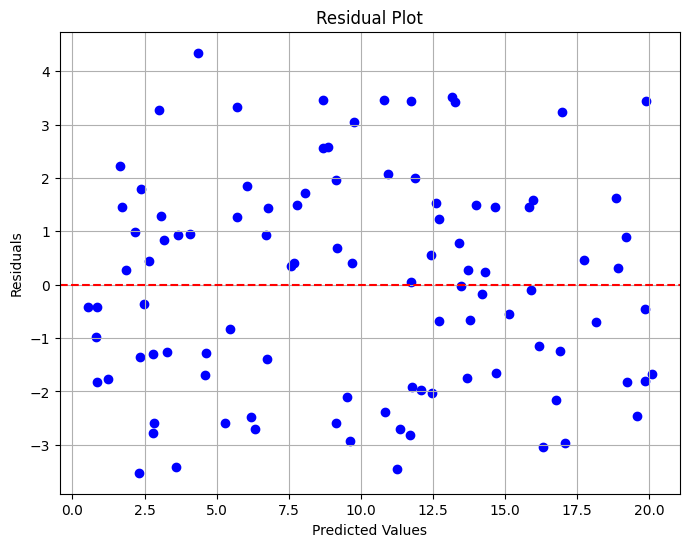

In [34]:
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + np.random.randn(100) * 2  # Adding random noise to the linear relationship

# Fit a linear regression model
model = LinearRegression()
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred

# Plot residuals against predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0 for reference
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

conclusion 

In [35]:

print("\nConclusions:")
print("- The Linear regression  model achieved a decent performance in predicting Indian summer temperatures.")
print("- The model's R2 score of", r2, "indicates that", round(r2*100, 2), "% of the variance in the temperature can be explained by the features.")
print("- However, there might be room for improvement as indicated by the Mean Absolute Error and Root Mean Squared Error.")






Conclusions:
- The Linear regression  model achieved a decent performance in predicting Indian summer temperatures.
- The model's R2 score of 0.9390074508833566 indicates that 93.9 % of the variance in the temperature can be explained by the features.
- However, there might be room for improvement as indicated by the Mean Absolute Error and Root Mean Squared Error.


 limitations of the dataset

In [36]:
# Discuss limitations of the dataset
print("\nLimitations of the Dataset:")
print("- The dataset might not include all relevant features that could affect temperature predictions, such as air pressure systems, geographical features, etc.")
print("- Data quality issues, such as missing or inaccurate data, could also impact the model's performance.")


Limitations of the Dataset:
- The dataset might not include all relevant features that could affect temperature predictions, such as air pressure systems, geographical features, etc.
- Data quality issues, such as missing or inaccurate data, could also impact the model's performance.


 Future Work

In [37]:

print("\n--- Future Work ---")
print("Potential future steps to enhance the model:")
print("- Explore ensemble methods like stacking or boosting to potentially improve prediction accuracy.")
print("- Consider employing deep learning algorithms, such as recurrent neural networks (RNNs) or convolutional neural networks (CNNs), which might capture more intricate patterns in the data.")
print("- Continuously update the model with new weather data to adapt to changing climate patterns and improve forecasting accuracy.")
print("- Incorporate additional features, such as satellite imagery data or geographical information, to provide a more comprehensive understanding of the factors influencing temperature variations.")


--- Future Work ---
Potential future steps to enhance the model:
- Explore ensemble methods like stacking or boosting to potentially improve prediction accuracy.
- Consider employing deep learning algorithms, such as recurrent neural networks (RNNs) or convolutional neural networks (CNNs), which might capture more intricate patterns in the data.
- Continuously update the model with new weather data to adapt to changing climate patterns and improve forecasting accuracy.
- Incorporate additional features, such as satellite imagery data or geographical information, to provide a more comprehensive understanding of the factors influencing temperature variations.
